In [44]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import nilearn.plotting as plotting
import nitools as nt
import nibabel as nb
import OptimalBattery.estimate as es




# define atlas and dirs

In [36]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

# Load data

- mdtb_1 - run: Data used to make libray of tasks and to use task batteries for parcellations
- mdtb_1 - all: Data used to pick the Vs of the top parcels
- mdtb_2 - all: Data used to test parcellation predicition error

In [7]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')


data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]



data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


recenter data around rest so that the variance in the Glibrary is signal compared to rest  
centers each row around the rest in its run and remove the rest row from each run


In [8]:
data_mdtb_s1_run,info_mdtb_1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run.shape)

data_mdtb_s1_all,info_mdtb_1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_all.shape)

(24, 448, 59518)
(24, 28, 59518)


# Define mask used for top parcel identification, Glibrary estimation and evaluation of predicition error

In [9]:
  # Load surface files for left and right hemispheres
surfs = [f"{func_fus_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6)):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}'
        )
    
    return fig


In [37]:
# Load glasser atlas
# roi (prefrontal cortex)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/glasser.L.label.gii'
model_name_R = f'{atlas_dir}/glasser.R.label.gii'
glasser_atlas = atlas.read_data([model_name_L,model_name_R])



In [38]:
# define PFC parcel and get the indices of the PFC parcels
PFC_parcels = ['OFC', '10pp', '10r', '8C', 's6-8', '25', 'p24', 'p47r', '46', 'a10p',
                          '10d', '9m', '8Av', 'IFJp', '10v', '13l', '45', 'i6-8', 
                          '9-46d', 'IFJa', '47s', 'SFL', 'a24', 'IFSp', '47m', 
                          '9p', '9a', 'pOFC', '8Ad', '11l', 'IFSa', 'a9-46v', 
                          '44', 'a47r', '55b', '47l', 's32', 'p9-46v',
                            '8BM', 'p10p', '8BL', 'p32', 'a32pr', 'd32']    # PNAS paper

# Load the GIFTI file
gifti_data = nb.load(model_name_L)
parcel_names = [label.label for label in gifti_data.labeltable.labels]
parcel_names = [name[len("L_"):] if name.startswith("L_") else name for name in parcel_names]
parcel_names = [name[:-len("_ROI")] if name.endswith("_ROI") else name for name in parcel_names]

# Get the indices of the PFC parcels
ROI_cortex = []
for name in PFC_parcels:
    ROI_cortex.append(parcel_names.index(name))


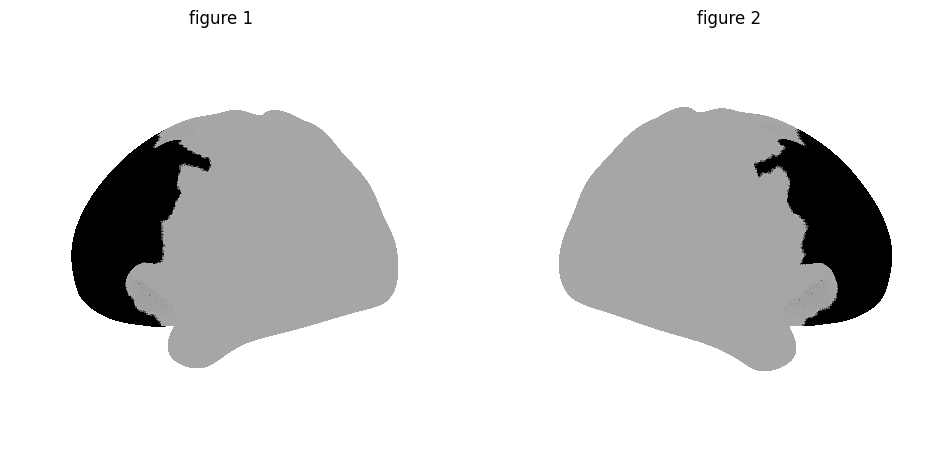

In [39]:
# make mask for PFC and plot 
ROI_mask = np.isin(glasser_atlas, ROI_cortex).astype(int)
mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

fig = plot_cortex(mask_reshaped, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()

In [41]:
# find indices where mask is 1 
ROI_indices = np.where(ROI_mask == 1)[0]
len(ROI_indices)

12094

# Get crossvalidated second moment matrix (GLib)

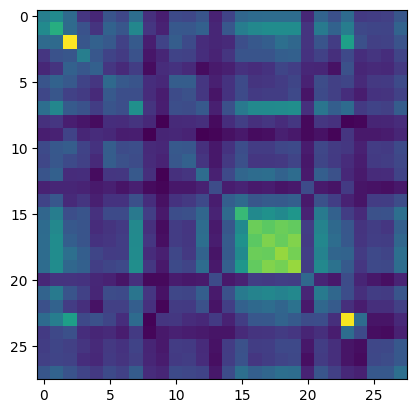

In [43]:
cond_vec = np.tile(np.arange(1, 28 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 28)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

# Build dataframes with different task battery size (n_tasks) and different number of parcels (n_parcels) and evaluate

In [54]:
battery_sizes = [3,4,5,6,7,8,10,12,14,16,18,20]
parcel_sizes = [2,4,6,8,10]
battery_sizes = [6]
parcel_sizes = [8]

In [55]:
results_df = pd.DataFrame()

for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")

        # only use top n parcels
        VLib, parcel_list = es.get_training_Vs(data_mdtb_s1_all,parcellation=glasser_atlas,ROI = ROI_mask, n_parcels=n_parcel)
        vtest = es.get_testing_Vs(data_mdtb_s2_all,parcellation=glasser_atlas,ROI = ROI_mask,selected_parcels=parcel_list)

        # Generate possible battery combinations for current battery size and evaluate each battery
        D = ut.build_combinations(G_Lib, strategy='random',n_iter=20000,n_tasks=n_task,seed=1,replacement=False)
        D = D.reset_index(drop=True)
        D_ev = ev.real_evaluate_dataframe_multiregion(D, data_mdtb_s1_run,info_mdtb_1_run,VLib,data_mdtb_s2_all, vtest,ROI_indices)

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
    


Processing parcel size: 8
Processing battery size: 6
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing combination: 9000
Processing combination: 10000
Processing combination: 11000
Processing combination: 12000
Processing combination: 13000
Processing combination: 14000
Processing combination: 15000
Processing combination: 16000
Processing combination: 17000
Processing combination: 18000
Processing combination: 19000


In [56]:
name = os.path.join(base_dir, 'OptimalBattery','Eval_tsvs', 'cortex-PFC_MDTB_ses-01_ses-02_results.tsv')

# save to tsv
# results_df.to_csv(name, sep="\t", index=False)

#load
results_df = pd.read_csv(name, sep="\t")

# Asses the different criteria

In [58]:
n_iter = 100
confidence = 0.95
metrics  = ["variance", "variance_mc","log_det_mc"]
bootstrap_results = []
battery_sizes = results_df['n_task'].unique()
parcel_sizes = results_df['n_parcel'].unique()

for i in parcel_sizes:
    print(f"Processing parcel size: {i}")
    for j in battery_sizes:
        print(f"Processing battery size: {j}")
        subset = results_df[(results_df['n_task'] == j) & (results_df['n_parcel'] == i)]
        num_samples = len(subset)
        metric_cos_values = {metric: [] for metric in metrics}
    
        for _ in range(n_iter):
            resampled = subset.sample(n=num_samples, replace=True)
            
            for metric in metrics:
                best_combination = resampled.nlargest(1, metric).sample(1)
                metric_cos_values[metric].append(best_combination['cos'])

        # Compute statistics for each metric
        for metric, cos_values in metric_cos_values.items():
            mean_cos = np.mean(cos_values)
            lower_ci, upper_ci = np.percentile(cos_values, [(1-confidence)/2 * 100, (1 + confidence)/2 * 100])
            
            bootstrap_results.append({
                'n_parcel': i,
                'n_task': j,
                'metric': metric,
                'mean_cos': mean_cos,
                'lower_ci': lower_ci,
                'upper_ci': upper_ci
            })

bootstrap_df = pd.DataFrame(bootstrap_results)


Processing parcel size: 2
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing battery size: 12
Processing battery size: 14
Processing battery size: 16
Processing battery size: 18
Processing battery size: 20
Processing battery size: 22
Processing battery size: 24
Processing parcel size: 4
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing battery size: 12
Processing battery size: 14
Processing battery size: 16
Processing battery size: 18
Processing battery size: 20
Processing battery size: 22
Processing battery size: 24
Processing parcel size: 6
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing batt

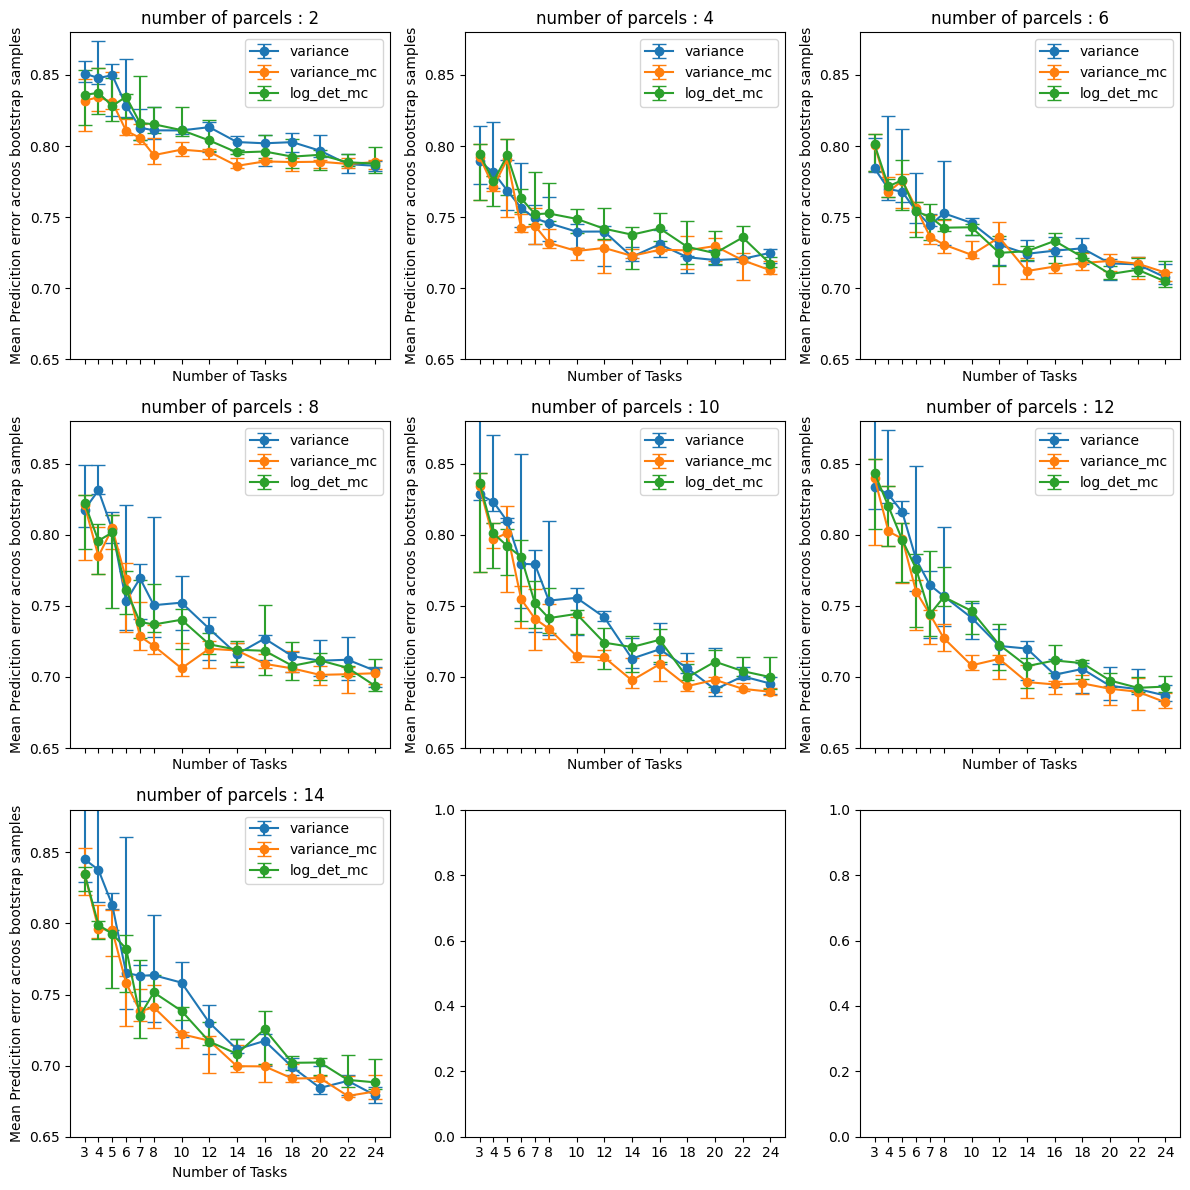

In [61]:
num_parcels = len(parcel_sizes)

# Determine grid layout (square-like)
ncols = int(np.ceil(np.sqrt(num_parcels)))  
nrows = int(np.ceil(num_parcels / ncols))  
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows), sharex=True)

axes = np.array(axes).flatten()

for ax, parcel in zip(axes, parcel_sizes):
    subset = bootstrap_df[bootstrap_df['n_parcel'] == parcel]

    for metric in metrics:
        metric_subset = subset[subset['metric'] == metric]
        ax.errorbar(
            metric_subset['n_task'], 
            metric_subset['mean_cos'], 
            yerr=[metric_subset['mean_cos'] - metric_subset['lower_ci'], 
                  metric_subset['upper_ci'] - metric_subset['mean_cos']], 
            fmt='o-', capsize=5, label=metric
        )

    ax.set_title(f"number of parcels : {parcel}")
    ax.set_xlabel("Number of Tasks")
    ax.set_ylabel("Mean Predicition error acroos bootstrap samples")
    ax.set_xticks(sorted(subset['n_task'].unique()))
    ax.legend()

    ax.set_ylim(0.65, 0.88)

plt.tight_layout()
plt.show()
